### Goal, look at if conserved indices in the MSA predict r_A, or if the same can be said of sector indices. 

Collect matrices which are (1) SCA sector 3/5 positions in MSA for each isolate sequence, (2) conserved positions in MSA for each isolate sequence, (3) a vector of r_A's for each sequence. 

Then, do PCA to get PCA coordinates for each of the three matrices. Run a LASSO to try to predict r_As from PCA coordinates. 

In [49]:
# load in the data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

conservation = np.load('../data/isolate_seqs/isolates_sca_results/conservation.npy')
msa = np.load('../data/isolate_seqs/isolates_sca_results/msa.npy')
seq_ids = np.load('../data/isolate_seqs/isolates_sca_results/retained_sequence_ids.npy')
sec3_pos = np.load('../data/isolate_seqs/isolates_sca_results/sector_3_msapos.npy')
sec5_pos = np.load('../data/isolate_seqs/isolates_sca_results/sector_5_msapos.npy')
sec3_scores = np.load('../data/isolate_seqs/isolates_sca_results/sector_3_scores.npy')
sec5_scores = np.load('../data/isolate_seqs/isolates_sca_results/sector_5_scores.npy')

strain_list = pd.read_csv('../data/isolate_seqs/strain_list.csv')
id_list_tot = strain_list['Strain'].values

indices = [] #indicies in the MSA corresponding to isolate strains
for i, seq in enumerate(seq_ids):
    if seq in id_list_tot:
        indices.append(i)
        
id_list = seq_ids[indices]

msa_isolates = msa[indices]


conserved_indices = np.where(conservation > np.mean(conservation) + 0.5*np.std(conservation))[0]
sec3_indices = np.where(sec3_scores > np.mean(sec3_scores) - 5*np.std(sec3_scores))[0]
sec5_indices = np.where(sec5_scores > np.mean(sec5_scores) - 5*np.std(sec5_scores))[0]
msa_conserved = msa_isolates[:, conserved_indices]

print('len(sec3_pos)', len(sec3_pos), 'len(sec3_scores)', len(sec3_scores))

sec3_indices = sec3_pos[sec3_indices]
sec5_indices = sec5_pos[sec5_indices]


msa_sec3 = msa_isolates[:, sec3_pos]
msa_sec5 = msa_isolates[:, sec5_pos]

# print(len(sec3_indices))
# print(len(sec5_indices))
# print(msa_sec5.shape)
print('sec 5 pos', sec5_pos)

import random
random_indices = random.sample(range(1, len(msa[0])), 50)
msa_random = msa_isolates[:, random_indices]
# print(len(conserved_indices))

# print(seq_ids[indices])
# print(id_list_tot)
# print("Missing ids:", set(id_list_tot) -  set(seq_ids[indices]))

FileNotFoundError: [Errno 2] No such file or directory: '../data/isolate_seqs/isolates_sca_results/conservation.npy'

In [ ]:
print(sec3_indices)
print(sec5_indices)

[ 42  83  32  36  40  53  75  22  18  60  86  56  35  84  21  73  72  68
  19  25  37  61  71  77  29  46  54  59  31  49  38  33  74 117  90  47
  94  12  78  97  82  34  28  41  87 100  26 116 134  93  24 113 135  52
 144 137 141 138 114  39 130 165 166 170 163 174 158 173  58 169 164 175
 107 153 123 146 177 160 162 121 101 126 186 184 119 145  55 106  96 180]
[1066 1109 1021 1110 1037 1085 1118 1101 1094 1119 1112 1099  998 1042
 1103 1075 1082 1050 1100 1001 1056 1084 1034 1080 1015 1115 1060 1045
 1088 1093 1010 1039 1035 1108  995 1026 1125 1027 1053 1016  997  993
 1086 1013 1054 1051 1044 1106 1004 1000 1006  994 1011  959 1067  967
  958 1102  948  966 1077  952  951  945  974 1074  949 1041]


### Collect rate parameters for the ids

In [ ]:

parameters = pd.read_csv('../data/isolate_seqs/consumer_resource_parameters_SDM.csv')
rates = parameters.set_index('Strain').reindex(id_list).iloc[:, 0].values
gammas = parameters.set_index('Strain').reindex(id_list).iloc[:, 1].values

### Perform PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
import numpy as np

import numpy as np

def hydrophobic_encoding(msa_matrix):
    """
    Replace amino acid numbers in MSA matrix with hydrophobicity values.
    
    Args:
        msa_matrix: numpy array with numbers representing amino acids
                   (using your DEFAULT_MAP: "ACDEFGHIKLMNPQRSTVWY" -> 0-19)
    
    Returns:
        numpy array with same shape as msa_matrix, but with hydrophobicity values
    """
    # Kyte-Doolittle hydrophobicity scale (most commonly used)
    # Mapping for "ACDEFGHIKLMNPQRSTVWY" in order
    hydrophobicity_scale = {
        0: 1.8,   # A - Alanine
        1: 2.5,   # C - Cysteine  
        2: -3.5,  # D - Aspartic Acid
        3: -3.5,  # E - Glutamic Acid
        4: 2.8,   # F - Phenylalanine
        5: -0.4,  # G - Glycine
        6: -3.2,  # H - Histidine
        7: 4.5,   # I - Isoleucine
        8: -3.9,  # K - Lysine
        9: 3.8,   # L - Leucine
        10: 1.9,  # M - Methionine
        11: -3.5, # N - Asparagine
        12: -1.6, # P - Proline
        13: -3.5, # Q - Glutamine
        14: -4.5, # R - Arginine
        15: -0.8, # S - Serine
        16: -0.7, # T - Threonine
        17: 4.2,  # V - Valine
        18: -0.9, # W - Tryptophan
        19: -1.3, # Y - Tyrosine
        20: 0.0   # Gap - neutral hydrophobicity
    }
    
    #create mapping
    vectorized_map = np.vectorize(lambda x: hydrophobicity_scale.get(x, 0.0))
    
    hydrophobicity_matrix = vectorized_map(msa_matrix)
    
    return hydrophobicity_matrix

def one_hot_encode_msa(msa_matrix):
    """
    Convert MSA matrix (n_sequences x n_positions) with values 0-20 
    """
    n_seqs, n_pos = msa_matrix.shape
    print(f"Original MSA shape: {msa_matrix.shape}")
    print(f"Unique values in data: {np.unique(msa_matrix)}")
    
    # Check if we have gaps (value 20) in this particular MSA
    has_gaps = 20 in msa_matrix
    if has_gaps:
        categories = [range(0, 21)]  # 0-20: 20 AAs + gaps
        n_categories = 21
    else:
        categories = [range(0, 20)]  # 0-19: 20 AAs only
        n_categories = 20
    
    # Reshape for one-hot encoding (flatten all positions)
    msa_flat = msa_matrix.reshape(-1, 1)
    
    # One-hot encode with appropriate categories
    encoder = OneHotEncoder(categories=categories, sparse_output=False)
    msa_onehot = encoder.fit_transform(msa_flat)
    
    # Reshape back to (n_sequences, n_positions * n_categories)
    msa_onehot = msa_onehot.reshape(n_seqs, -1)
    print(f"One-hot encoded shape: {msa_onehot.shape}")
    print(f"Total features: {n_pos} positions × {n_categories} categories = {msa_onehot.shape[1]} columns")
    
    return msa_onehot

def compute_pca_components(data, n_components=3):
    pca = PCA(n_components=n_components)
    pca_components = pca.fit_transform(data)
    explained_ratio = pca.explained_variance_ratio_
    return pca_components, explained_ratio

# Process each MSA sector
print("MSA Sector 3 PCA:")
msa_sec3_onehot = hydrophobic_encoding(msa_sec3)
pca_sec3, explained_sec3 = compute_pca_components(msa_sec3_onehot)
print(f"Explained variance ratio: {explained_sec3}")
print(f"Total variance explained: {np.sum(explained_sec3):.4f}")
print(f"PCA shape: {pca_sec3.shape}\n")

print("MSA Sector 5 PCA:")
msa_sec5_onehot = hydrophobic_encoding(msa_sec5)
pca_sec5, explained_sec5 = compute_pca_components(msa_sec5_onehot)
print(f"Explained variance ratio: {explained_sec5}")
print(f"Total variance explained: {np.sum(explained_sec5):.4f}")
print(f"PCA shape: {pca_sec5.shape}\n")

print("MSA Conserved PCA:")
msa_conserved_onehot = hydrophobic_encoding(msa_conserved)
pca_conserved, explained_conserved = compute_pca_components(msa_conserved_onehot)
print(f"Explained variance ratio: {explained_conserved}")
print(f"Total variance explained: {np.sum(explained_conserved):.4f}")
print(f"PCA shape: {pca_conserved.shape}\n")

print("MSA Random PCA:")
msa_conserved_random = hydrophobic_encoding(msa_random)
pca_random, explained_random = compute_pca_components(msa_conserved_random)
print(f"Explained variance ratio: {explained_random}")
print(f"Total variance explained: {np.sum(explained_random):.4f}")
print(f"PCA shape: {pca_conserved.shape}\n")



MSA Sector 3 PCA:
Explained variance ratio: [0.31612625 0.21050155 0.16443775]
Total variance explained: 0.6911
PCA shape: (51, 3)

MSA Sector 5 PCA:
Explained variance ratio: [0.60179758 0.22451263 0.08537662]
Total variance explained: 0.9117
PCA shape: (51, 3)

MSA Conserved PCA:
Explained variance ratio: [0.29744751 0.15470765 0.15185068]
Total variance explained: 0.6040
PCA shape: (51, 3)

MSA Random PCA:
Explained variance ratio: [0.33119645 0.22303421 0.13252448]
Total variance explained: 0.6868
PCA shape: (51, 3)



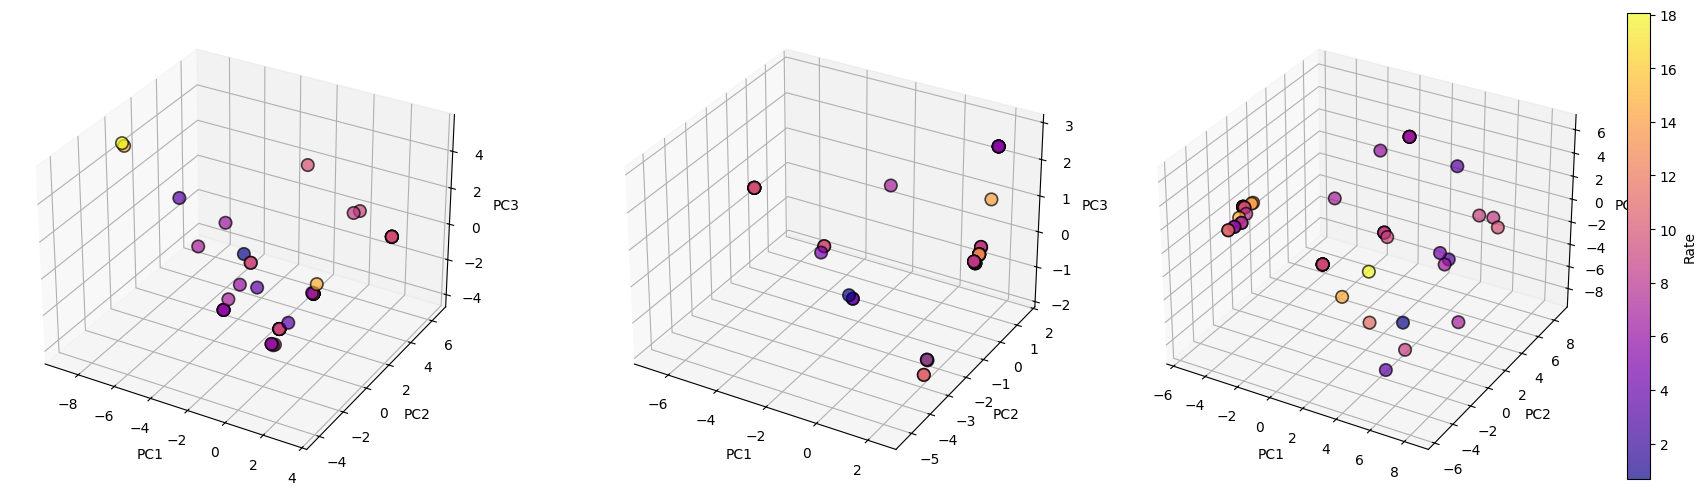

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create the plots
fig = plt.figure(figsize=(18, 5))

# Plot 1: Sector 3
ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(pca_sec3[:, 0], pca_sec3[:, 1], pca_sec3[:, 2], c=rates, cmap='plasma', 
                 s=80, edgecolor='black', linewidth=1.2, alpha=0.7)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')

# Plot 2: Sector 5
ax2 = fig.add_subplot(132, projection='3d')
sc2 = ax2.scatter(pca_sec5[:, 0], pca_sec5[:, 1], pca_sec5[:, 2], c=rates, cmap='plasma', 
                 s=80, edgecolor='black', linewidth=1.2, alpha=0.7)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')

# Plot 3: Conserved
ax3 = fig.add_subplot(133, projection = '3d')
sc3 = ax3.scatter(pca_random[:, 0], pca_random[:, 1], pca_random[:, 2], c=rates, cmap='plasma', 
                 s=80, edgecolor='black', linewidth=1.2, alpha=0.7)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_zlabel('PC3')
plt.colorbar(sc3, ax=ax3, label='Rate')

plt.tight_layout()
plt.show()


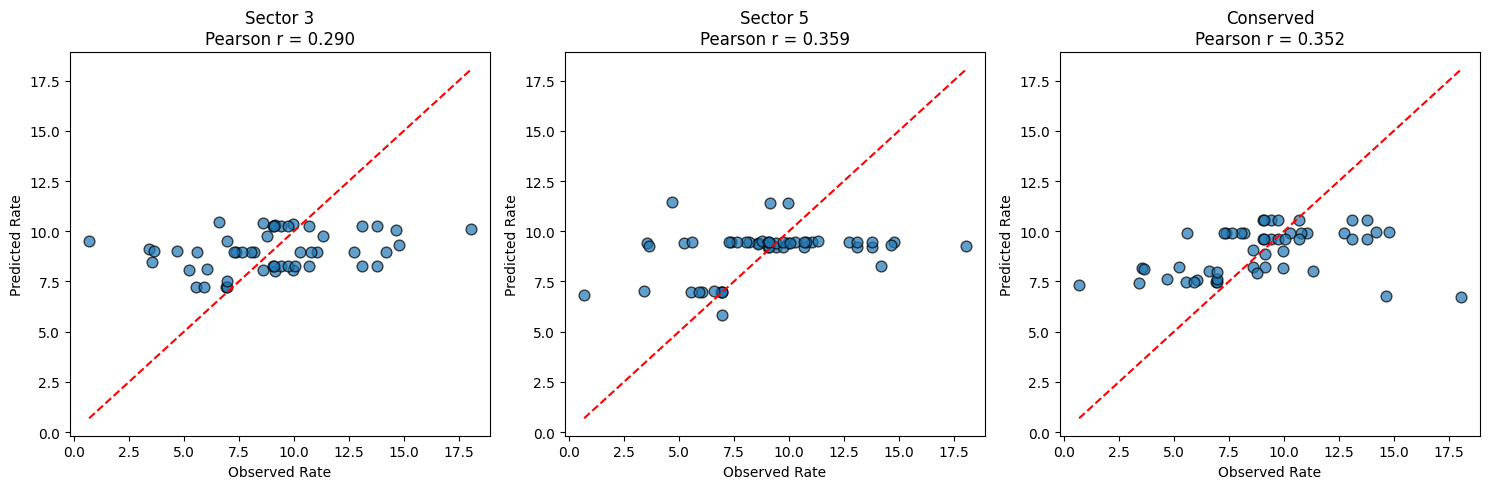

In [ ]:
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Create the plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sector 3 regression
model_sec3 = LinearRegression()
model_sec3.fit(pca_sec3, rates)
pred_sec3 = model_sec3.predict(pca_sec3)
corr_sec3, _ = pearsonr(pred_sec3, rates)

axes[0].scatter(rates, pred_sec3, alpha=0.7, s=60, edgecolor='black')
min_val = min(rates.min(), pred_sec3.min())
max_val = max(rates.max(), pred_sec3.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[0].set_xlabel('Observed Rate')
axes[0].set_ylabel('Predicted Rate')
axes[0].set_title(f'Sector 3\nPearson r = {corr_sec3:.3f}')

# Sector 5 regression
model_sec5 = LinearRegression()
model_sec5.fit(pca_sec5, rates)
pred_sec5 = model_sec5.predict(pca_sec5)
corr_sec5, _ = pearsonr(pred_sec5, rates)

axes[1].scatter(rates, pred_sec5, alpha=0.7, s=60, edgecolor='black')
min_val = min(rates.min(), pred_sec5.min())
max_val = max(rates.max(), pred_sec5.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[1].set_xlabel('Observed Rate')
axes[1].set_ylabel('Predicted Rate')
axes[1].set_title(f'Sector 5\nPearson r = {corr_sec5:.3f}')

# Conserved regression
model_cons = LinearRegression()
model_cons.fit(pca_conserved, rates)
pred_cons = model_cons.predict(pca_conserved)
corr_cons, _ = pearsonr(pred_cons, rates)

axes[2].scatter(rates, pred_cons, alpha=0.7, s=60, edgecolor='black')
min_val = min(rates.min(), pred_cons.min())
max_val = max(rates.max(), pred_cons.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[2].set_xlabel('Observed Rate')
axes[2].set_ylabel('Predicted Rate')
axes[2].set_title(f'Conserved\nPearson r = {corr_cons:.3f}')

plt.tight_layout()
plt.show()

### a null? 

### Try a LASSO directly mapping onto r_A from the one hot encoding

In [ ]:


def msa_regression(msa, values, test_size=0.2, random_state=42):
    """
    Lasso regression for MSA one-hot encoded data (sets coefficients to zero)
    """
    # Automatically split the data
    X_train, X_test, y_train, y_test = train_test_split(
        msa, values, 
        test_size=test_size, 
        random_state=random_state
    )
    
    print(f"Data split: {X_train.shape[0]} training sequences, {X_test.shape[0]} test sequences")
    print(f"Features per sequence: {X_train.shape[1]}")
    
    # Standardize features (important for Lasso)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Use Lasso regression with cross-validated alpha
    model = LassoCV(
        alphas=np.logspace(-2, 2, 50),  # Range of regularization strengths
        cv=5,  # 5-fold cross-validation
        max_iter=10000,  # More iterations for convergence
        random_state=random_state
    )
    

    model.fit(X_train_scaled, y_train)
    
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    #metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    #non-zero coefficients (feature selection)
    n_nonzero = np.sum(model.coef_ != 0)
    # print('model coefficients', model.coef_)
    # Print results
    print(f"\nLASSO RESULTS:")
    print(f"Best regularization strength (alpha): {model.alpha_:.6f}")
    print(f"Non-zero coefficients: {n_nonzero} out of {len(model.coef_)} ({n_nonzero/len(model.coef_)*100:.1f}%)")
    print(f"Training R²: {train_r2:.3f}")
    print(f"Test R²: {test_r2:.3f}")
    
    

    plt.figure(figsize=(8, 6))


    plt.scatter(y_train, y_pred_train, alpha=0.7, color='blue', label='Training data')

    plt.scatter(y_test, y_pred_test, alpha=0.7, color='darkviolet', label='Test data')

    all_obs = np.concatenate([y_train, y_test])
    all_pred = np.concatenate([y_pred_train, y_pred_test])
    plt.plot([all_obs.min() - 0.1, all_obs.max() + 0.1], [all_obs.min() - 0.1, all_obs.max() + 0.1], lw=2, color = 'Black', alpha = 0.7)
    plt.xlim(all_obs.min()- 0.1 , all_obs.max()+ 0.1)
    plt.xlabel('Observed $r_A$')
    plt.ylabel('Predicted $r_A$')
    plt.legend()

    plt.text(0.05, 0.95, f'Training R² = {train_r2:.3f}', transform=plt.gca().transAxes, 
            color='blue', fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.88, f'Test R² = {test_r2:.3f}', transform=plt.gca().transAxes, 
            color='darkviolet', fontsize=12, verticalalignment='top')

    plt.show()
    
    plt.tight_layout()
    plt.show()
    
    return {
        'model': model,
        'scaler': scaler,
        'y_train': y_train,
        'y_test': y_test, 
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'n_nonzero_coef': n_nonzero,
        'total_features': len(model.coef_),
        'coefficients': model.coef_
    }

Data split: 40 training sequences, 11 test sequences
Features per sequence: 534

LASSO RESULTS:
Best regularization strength (alpha): 0.014563
Non-zero coefficients: 35 out of 534 (6.6%)
Training R²: 0.871
Test R²: 0.515


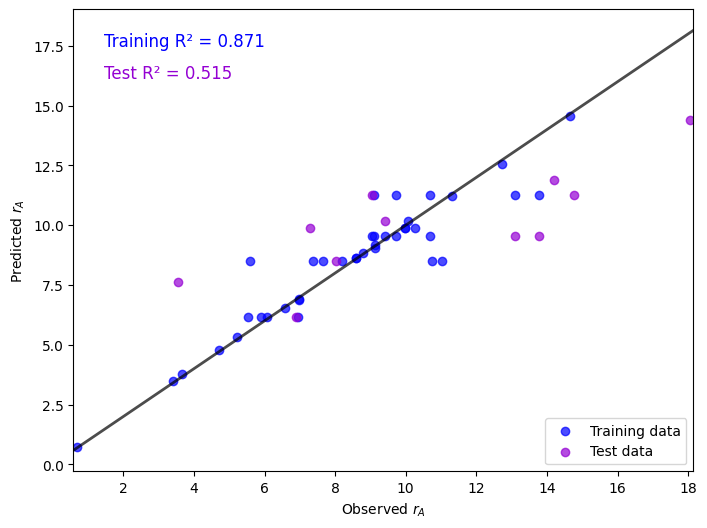

<Figure size 640x480 with 0 Axes>

In [50]:
msa_encoding = hydrophobic_encoding(msa_conserved) 

results = msa_regression(msa_encoding, rates, test_size=0.2, random_state=42)

[  34   44  260  273  323  353  382  417  425  436  548  551  579  594
  615  623  654  657  712  739  756  759  782  795  813  821  855  936
  949  954  972  973 1058 1103 1126]


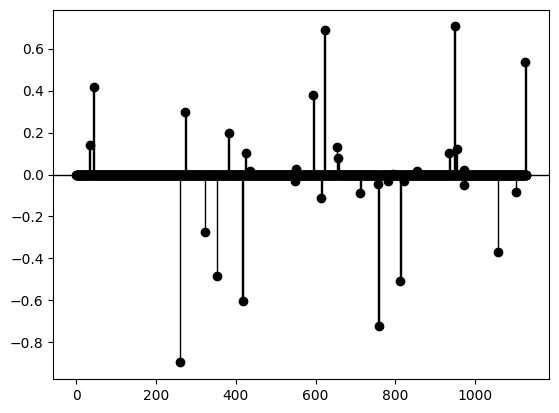

In [ ]:
import numpy as np
selected_indices = np.where(results['coefficients'] != 0)
indices = conserved_indices[selected_indices]
print(indices)
coefficients = results['coefficients']
y = np.zeros(len(msa[0]))
y[indices] = coefficients[selected_indices]
plt.bar(range(len(y)), y, width=2, color = 'Navy', edgecolor = 'Black')
plt.scatter(range(len(y)), y, color = 'Black')
plt.axhline(y=0, color='black', linewidth=1)

(51, 35)


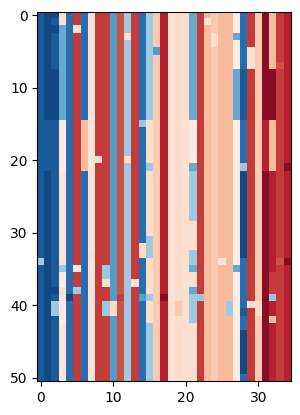

In [ ]:
print(msa_encoding[:, selected_indices[0]].shape)

plt.imshow(msa_encoding[:, selected_indices[0]], cmap = 'RdBu', vmin = -5, vmax = 5)



In [ ]:
print(sec3_indices)
print(sec5_indices)
print(sec5_scores)
print(len(sec5_scores))

[ 42  83  32  36  40  53  75  22  18  60  86  56  35  84  21  73  72  68
  19  25  37  61  71  77  29  46  54  59  31  49  38  33  74 117  90  47
  94  12  78  97  82  34  28  41  87 100  26 116 134  93  24 113 135  52
 144 137 141 138 114  39 130 165 166 170 163 174 158 173  58 169 164 175
 107 153 123 146 177 160 162 121 101 126 186 184 119 145  55 106  96 180]
[1066 1109 1021 1110 1037 1085 1118 1101 1094 1119 1112 1099  998 1042
 1103 1075 1082 1050 1100 1001 1056 1084 1034 1080 1015 1115 1060 1045
 1088 1093 1010 1039 1035 1108  995 1026 1125 1027 1053 1016  997  993
 1086 1013 1054 1051 1044 1106 1004 1000 1006  994 1011  959 1067  967
  958 1102  948  966 1077  952  951  945  974 1074  949 1041]
[0.16390291 0.15463839 0.15328012 0.15108304 0.15102822 0.14853797
 0.14804228 0.14635419 0.14080827 0.13990812 0.13852742 0.13674974
 0.13616441 0.13493479 0.13400733 0.13124481 0.13052389 0.12920479
 0.12835382 0.12834443 0.1263085  0.12569655 0.12523781 0.12417885
 0.12274256 0.121951

(51, 90)
(51, 68)


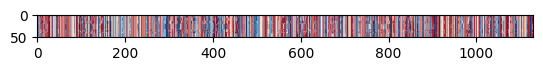

In [ ]:
print(msa_sec3.shape)
print(msa_sec5.shape)

plt.imshow(hydrophobic_encoding(msa_isolates), cmap = 'RdBu')
# plt.imshow(hydrophobic_encoding(msa_sec5))
# plt.imshow(hydrophobic_encoding(msa_isolates))